# Black Hole Imaging from GRMHD Simulations

In this notebook, we explore how to generate synthetic images of black holes using data from General Relativistic Magnetohydrodynamic (GRMHD) simulations.

## First, we import the necessary functions to perform such calculations.

- The file main.jl serves as a wrapper for this for us

In [ ]:
# ─── Configuración del modelo de simulación ───────────────────────────────

# MODEL: indica qué formato de datos GRMHD se usará.
# "iharm" corresponde al formato de salida del código iharm3d,
# un solver de GRMHD ampliamente usado en astrofísica de agujeros negros.
const MODEL = "iharm"

# MBH: masa del agujero negro en masas solares.
# 6.2e9 M☉ corresponde a la masa de M87*, medida por el EHT.
const MBH = 6.2e9

# SLOW_LIGHT: activa o desactiva la aproximación de "luz lenta" (slow-light).
# Si es false, se usa la aproximación de luz rápida (fast-light), donde
# se ignora la variabilidad temporal del plasma durante el trazado de rayos.
# Si es true, se tiene en cuenta que el plasma cambia mientras el fotón viaja.
const SLOW_LIGHT = false

# Carga el archivo principal del proyecto Jipole, que actúa como wrapper
# e importa todas las funciones necesarias para raytracing, lectura de datos, etc.
include("../src/main.jl");


## Now we point to the path of the GRMHD snapshot/dumpfile.

- Currently, Jipole only reads `iharm3d` data format.

To access the file used in this notebook, download the snapshot from [Harvard Dataverse (GRMHD snapshot)](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/XZECPF)

In [ ]:
# ─── Ruta al archivo de snapshot GRMHD ────────────────────────────────────────

# dump_filepath: ruta local al archivo HDF5 (.h5) que contiene el snapshot
# de la simulación GRMHD. Este archivo almacena las variables primitivas
# del plasma (densidad, energía, velocidades, campo magnético) en una grilla
# tridimensional en coordenadas de Kerr modificadas (MKS).
#
# El archivo de ejemplo corresponde a una simulación SANE (Standard And Normal
# Evolution) con spin a = +0.94, en coordenadas MKS, paso de tiempo 0900.
# Se puede descargar desde Harvard Dataverse:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/XZECPF
dump_filepath = "C:/Users/danyp/OneDrive/Escritorio/CosasPater/jipoleProyect/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

## Magnetization parameters

We begin by defining a set of parameters that will be used when reading and processing the GRMHD simulation data

- `trat_large:` Ratio of ion-to-electron temperature in low-magnetization regions (disk-dominated plasma). This controls how hot electrons are relative to ions in the bulk flow.
- `trat_small:` Ion-to-electron temperature ratio in highly magnetized regions (jet-dominated plasma). A value closer to 1 implies electrons and ions have similar temperatures.
- `beta_crit:` Critical plasma beta (ratio of gas pressure to magnetic pressure) that determines the transition between disk-like and jet-like thermodynamic prescriptions.
- `th_beg:`   Lower cutoff for the polar angle (in radians), typically used to exclude regions too close to the poles where numerical artifacts or low-density funnels may exist.
- `sigma_cut:` Magnetization threshold (σ = magnetic energy density / matter energy density) above which zones may be excluded or treated differently due to strong magnetic dominance.
- `sigma_cut_high:` Upper magnetization cutoff. A negative value typically indicates that no upper limit is enforced.

In [ ]:
# ─── Parámetros de magnetización y termodinámica del plasma ──────────────────

# trat_large: razón de temperatura ion/electrón en regiones de BAJA magnetización
# (disco de acreción). Un valor de 20 significa que los iones están mucho más
# calientes que los electrones en el disco.
# Sigue la prescripción Rhigh del modelo R-β (Mościbrodzka et al. 2016, A&A, 586, A38).
trat_large = 20.

# trat_small: razón T_ion/T_electrón en regiones de ALTA magnetización (jet).
# Un valor de 1 implica que iones y electrones tienen la misma temperatura en el jet.
const trat_small = 1.

# beta_crit: valor crítico del parámetro beta del plasma (presión de gas / presión magnética)
# que marca la transición entre el régimen del disco (beta > beta_crit) y el jet (beta < beta_crit).
# beta = 1 implica que ambas presiones son iguales en el punto de transición.
const beta_crit = 1.0

# th_beg: ángulo polar mínimo (en radianes) considerado en la integración.
# Se excluyen regiones muy cercanas al eje de rotación (polo) para evitar
# artefactos numéricos o el funnel de baja densidad del jet.
# 1.74e-2 rad ≈ 1 grado.
const th_beg = 1.74e-2

# sigma_cut: umbral de magnetización σ = b²/ρ (energía magnética / energía de la materia)
# por encima del cual las celdas se excluyen del cálculo radiativo.
# Evita contaminar la imagen con emisión de regiones dominadas por campo magnético
# donde el plasma GRMHD es numéricamente poco fiable.
const sigma_cut = 1.0

# sigma_cut_high: límite superior de σ. Un valor negativo indica que no
# se aplica ningún corte superior (sin límite máximo de magnetización).
const sigma_cut_high = -1.0;


## Simulation Parameters Structure
We define a `GlobalParams` structure that stores all the relevant metadata quantities describing the GRMHD simulation. These parameters are read from the simulation header and are required to interpret the data in the dump file.

### Overview

The structure includes:

- **Flags**
  - `metric`, `ELECTRONS`, `RADIATION`  
    Integer flags indicating the spacetime metric used and whether electron physics and radiation are included in the simulation.

- **Physical Parameters**
  - `gam`, `game`, `gamp`  
    Adiabatic indices for the total fluid, electrons, and protons.
  - `Te_unit`, `Thetae_unit`  
    Conversion factors for electron temperature into physical or dimensionless units.

- **Particle Weights**
  - `mu_i`, `mu_e`, `mu_tot`  
    Mean molecular weights for ions, electrons, and the total plasma.
  - `Ne_factor`  
    Scaling factor used to compute electron number density.

- **Units**
  - `M_unit`, `T_unit`, `L_unit`  
    Unit conversions for mass, time, and length.
  - `MBH`  
    Black hole mass used to scale the simulation.
  - `tp_over_te`  
    Ratio of proton to electron temperature.

- **Metric Parameters**
  - `a`  
    Dimensionless black hole spin.
  - `hslope`, `Rin`, `Rout`  
    Parameters defining the radial and angular grid structure.
  - `poly_xt`, `poly_alpha`, `mks_smooth`, `poly_norm`  
    Parameters controlling coordinate transformations and grid shaping.

- **MKS3-Specific Parameters**
  - `mks3R0`, `mks3H0`, `mks3MY1`, `mks3MY2`, `mks3MP0`  
    Additional parameters for modified Kerr–Schild (MKS3) coordinate systems.

- **Grid Configuration**
  - `N1`, `N2`, `N3`  
    Number of grid cells in each spatial dimension.
  - `dx`  
    Grid spacing in each coordinate direction.
  - `startx`, `stopx`  
    Domain boundaries.
  - `cstartx`, `cstopx`  
    Cell-centered domain boundaries.

- **Geometric Limits**
  - `rmin_geo`, `rmax_geo`  
    Minimum and maximum radii of the computational domain in geometric units.

Together, these parameters describe the simulation setup, coordinate system, physical scaling, and numerical grid.

In [ ]:
# ─── Lectura del encabezado del archivo de simulación ────────────────────────

# read_header: lee el bloque de metadatos (header) del archivo HDF5 de la simulación.
# Extrae y devuelve una estructura GlobalParams que contiene:
#   - Parámetros físicos: índice adiabático (gam), unidades de masa/tiempo/longitud
#   - Parámetros de la métrica: spin (a), Rin, Rout, hslope, etc.
#   - Configuración de la grilla numérica: N1, N2, N3, dx, startx, stopx
#   - Flags: tipo de métrica, si se incluyen electrones, radiación, etc.
#
# Esta información es necesaria para interpretar correctamente los datos del dump
# y para configurar el trazado de geodésicas en la métrica de Kerr.
const params = read_header(dump_filepath);


## Simulation Data (Primitive Variables)

The simulation data structure stores the **primitive variables** extracted from the GRMHD dump file, along with some derived quantities.
### Primitive Variables
- `RHO`  
  Rest-mass density of the fluid.
- `UU`  
  Internal energy density.
- `U1`, `U2`, `U3`  
  Spatial components of the fluid 4-velocity.
- `B1`, `B2`, `B3`  
  Magnetic field components defined in the simulation frame.
### Derived Quantities
- `ne`  
  Electron number density, computed using the density and composition assumptions.
- `b`  
  Magnetic field strength (magnitude of the magnetic 4-vector).
- `θe`  
  Dimensionless electron temperature.
- `sigma`  
  Magnetization parameter (ratio of magnetic to matter energy density).
- `beta`  
  Plasma beta, defined as the ratio of gas pressure to magnetic pressure.
- `dθedRhi`  
  Radial gradient of the electron temperature in high-magnetization regions, used when doing the autodiff analysis on Rhigh

In [ ]:
# ─── Carga de las variables primitivas de la simulación ──────────────────────

# Se crea un Vector de tipo IharmData de longitud 1 (sin inicializar).
# El uso de Vector{IharmData} en lugar de una variable simple permite
# generalizar a múltiples snapshots o simulaciones (modo multi-frame).
const simulation_data = Vector{IharmData}(undef, 1)

# load_data: lee el archivo de dump y extrae las variables primitivas del plasma:
#   - RHO  → densidad de masa en reposo
#   - UU   → densidad de energía interna
#   - U1,U2,U3 → componentes de la 4-velocidad del fluido
#   - B1,B2,B3 → componentes del campo magnético en el frame de la simulación
# Además calcula cantidades derivadas:
#   - ne (densidad electrónica), b (intensidad B), θe (temperatura electrónica),
#     sigma (magnetización), beta (β del plasma)
#
# trat_large se pasa para calcular la temperatura de electrones
# según la prescripción R-β en el disco.
simulation_data[1] = load_data(dump_filepath, trat_large);


## Defining the parameters for the Raytracing

In [ ]:
# ─── Parámetros del observador y la cámara ───────────────────────────────────

# Distancia del observador al agujero negro, en unidades de radios gravitacionales (Rg).
# Rg = GM/c². A 1000 Rg el observador está efectivamente en el infinito asintótico
# para los efectos de la métrica de Kerr.
const ro = 1000.0

# Ángulo de inclinación del observador respecto al eje de spin del agujero negro (en grados).
# 163° significa que el observador está ligeramente por debajo del plano ecuatorial
# (equivalente a 17° desde el polo sur). Valor consistente con observaciones del EHT de M87*.
# Referencia: EHT Collaboration (2019), ApJL, 875, L5.
const th = 60.0 #¿por qué no 17°?

# Ángulo azimutal del observador alrededor del sistema (en grados).
# phi = 0 es la posición de referencia; normalmente no afecta imágenes promediadas en phi.
const phi = 0.0

# Resolución de la imagen: se trazarán res² = 1024² = 1,048,576 geodésicas (una por píxel).
const res = 1024
const pixels_x = 1024   # número de píxeles en la dirección x del plano imagen
const pixels_y = 1024   # número de píxeles en la dirección y del plano imagen

# Distancia física a la fuente (M87*): 16.9 Mpc convertidos a cm usando la constante PC
# (1 parsec en cm, definida en main.jl). La distancia a M87* es ~16.8 Mpc.
# Referencia: EHT Collaboration (2019), ApJL, 875, L6.
const SourceD = 16.9e6 * PC

# Radio del horizonte de eventos para un agujero negro de Kerr en unidades geométricas.
# Fórmula analítica: r+ = M + √(M² - a²), con M=1 en unidades geométricas.
# params.a es el spin adimensional (a/M), leído del header de la simulación.
const Rh = 1 + sqrt(1. - params.a * params.a)

# Frecuencia de observación en Hz. 230 GHz es la frecuencia central del EHT,
# correspondiente a una longitud de onda de ~1.3 mm.
# Referencia: EHT Collaboration (2019), ApJL, 875, L2.
const freq = 230e9

# Tamaño físico del plano imagen en unidades de Rg.
# Se calcula a partir de la distancia a la fuente, la unidad de longitud (L_unit),
# y el factor de conversión a microarcosegundos (MUAS_PER_RAD).
# El factor 160 define el campo de visión total en μas del plano imagen.
const DXsize = SourceD / L_unit / MUAS_PER_RAD * 160
const DYsize = SourceD / L_unit / MUAS_PER_RAD * 160

# Campo de visión angular (en radianes) de la imagen, en cada dirección.
# Se divide el tamaño físico por la distancia del observador para obtener el ángulo.
const fovx = DXsize / ro
const fovy = DYsize / ro

# Desplazamiento del centro de la imagen en el plano focal.
# Con xoff=yoff=0, el agujero negro queda centrado en la imagen.
const xoff = 0.0
const yoff = 0.0;


In [ ]:
println("Resolution:        $(pixels_x) × $(pixels_y) pixels")
println("Inclination:       th = $(th)° (equivalent to $(180 - th)° from the jet axis)")
println("Spin:              a = $(params.a)")
println("Frequency:         $(freq/1e9) GHz")
println("Observer distance: ro = $(ro) Rg")
println("Field of view:     $(DXsize * L_unit / SourceD * MUAS_PER_RAD) μas")

## Performing the Image calculation

In [7]:
# ─── Trazado de rayos (Raytracing) y cálculo de la imagen ────────────────────

using ProgressMeter   # Paquete para mostrar barras de progreso en Julia

# Calcula la posición de la cámara (observador) en coordenadas nativas de la simulación
# (coordenadas MKS modificadas). La función camera_position convierte las coordenadas
# esféricas (ro, th, phi) a las coordenadas internas usadas por el código.
# MVec4 crea un vector mutable de 4 componentes (coordenadas espaciotemporales).
Xcamera = MVec4(camera_position(ro, th, phi, params.a, params.Rout))

# Frecuencia adimensional del fotón: ν_adim = hν / (m_e c²)
# donde HPL = constante de Planck, ME = masa del electrón, CL = velocidad de la luz.
# Esta normalización es necesaria para los cálculos de emisión/absorción del plasma.
const freq_unitless = freq * HPL / (ME * CL * CL)

# Arreglo 2D que almacenará la intensidad específica (Iν) calculada para cada píxel.
# Inicializado en cero; se llenará durante el loop de raytracing.
Image = zeros(Float64, pixels_x, pixels_y)

# Número de hilos de CPU disponibles + 1 (para el hilo principal).
# Usado para paralelizar el trazado de rayos con Threads.@threads.
const nthreads = Threads.nthreads() + 1

println("Allocating workspaces for $nthreads threads...")

# Número máximo de pasos de integración numérica por geodésica.
# Una geodésica que requiera más de 15000 pasos se considera que no converge
# o que llega al horizonte de eventos / límite del dominio.
const maxnstep = 15000

# Estructuras de trabajo para almacenar la trayectoria de cada fotón.
# dummy_svec: vector estático de 4 componentes inicializado a cero (posición/momento).
# @SVector crea un vector estático (inmutable, en stack) para mejor rendimiento.
dummy_svec = @SVector zeros(4)

# dummy_traj: elemento de trayectoria vacío (tipo OfTrajS) con posición y momento en cero.
# OfTrajS almacena: paso de affine, posición X, momento p, y dos cantidades auxiliares.
dummy_traj = OfTrajS(0.0, dummy_svec, dummy_svec, dummy_svec, dummy_svec)

# Se crea un vector de trayectorias por hilo para evitar condiciones de carrera.
# Cada hilo tiene su propio buffer de maxnstep pasos, inicializado con dummy_traj.
thread_trajs = [Vector{OfTrajS}(undef, maxnstep) for _ in 1:nthreads]
for t in 1:nthreads
    for k in 1:maxnstep
        thread_trajs[t][k] = dummy_traj
    end
end

# Barra de progreso: muestra el avance del raytracing píxel a píxel.
# pixels_x * pixels_y = número total de fotones a trazar.
p = Progress(
    pixels_x * pixels_y;
    desc = "Raytracing Image...",
    showspeed = true,
    barlen = 30
)
ProgressMeter.ijulia_behavior(:clear)   # Comportamiento de limpieza en Jupyter

println("Tracing Geodesics...")

# ─── Loop principal de trazado de rayos (paralelizado) ───────────────────────
# Threads.@threads distribuye el loop externo (sobre i) entre los hilos disponibles.
# Cada hilo procesa una columna completa de píxeles de forma independiente.
Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid()   # ID del hilo actual (para acceder a su buffer propio)

    for j in 0:(pixels_y - 1)

        # get_pixel: traza la geodésica nula (trayectoria del fotón) correspondiente
        # al píxel (i,j) del plano imagen. Integra las ecuaciones de la geodésica
        # hacia atrás desde el observador hasta que el rayo alcanza el horizonte de
        # eventos, sale del dominio, o supera maxnstep pasos.
        # Devuelve: nstep (número de pasos efectivos usados) y un valor auxiliar.
        nstep, _ = get_pixel(
            thread_trajs[tid], i, j, Xcamera,
            fovx, fovy, freq_unitless,
            pixels_x, pixels_y, params.a,
            Rh, params.Rout, params.rmax_geo, xoff, yoff
        )

        # integrate_emission!: integra la ecuación de transferencia radiativa
        # a lo largo de la geodésica almacenada en thread_trajs[tid].
        # Para cada punto de la trayectoria, interpola las variables del plasma
        # (densidad, temperatura, campo B) y calcula emisión y absorción
        # de sincrotrón (el mecanismo dominante en fuentes como M87*).
        # El resultado (intensidad Iν) se acumula en Image[i+1, j+1].
        # El signo ! indica que la función modifica Image in-place (convención Julia).
        integrate_emission!(
            thread_trajs[tid], nstep, Image,
            i + 1, j + 1, freq, params.a, simulation_data
        )

        # Actualiza la barra de progreso con información del hilo y píxel actual.
        ProgressMeter.next!(
            p;
            showvalues = [
                (:thread_id, tid),
                (:pixel, "($i, $j)"),
                (:total_done, "$(i*pixels_y + j)/$(pixels_x * pixels_y)")
            ]
        )
    end
end

# Corrección por el factor ν³ de la invariante de Lorentz de la intensidad específica.
# En transferencia radiativa relativista, la cantidad conservada a lo largo
# de una geodésica es Iν/ν³ (invariante de Lorentz). Al integrar se acumula
# Iν/ν³, por lo que se multiplica por freq³ para recuperar Iν en el frame del observador.
# Referencia: Mihalas & Mihalas (1984), "Foundations of Radiation Hydrodynamics".
Image *= freq^3

finish!(p);   # Cierra y finaliza la barra de progreso


Raytracing Image... 100%|██████████████████████████████| Time: 0:04:15 ( 0.24 ms/it)
    thread_id: 17
        pixel: (831, 1023)
   total_done: 851967/1048576


## Print out some outputs

In [10]:
# ─── Cálculo del factor de escala y parámetros de Stokes ─────────────────────

# CalculateScaleFactor: calcula el factor que convierte las unidades internas
# del código (adimensionales) a unidades físicas de intensidad específica
# (Jy/sr o Jy/beam, según contexto). Depende del tamaño angular del plano imagen,
# la resolución en píxeles, la distancia a la fuente y la unidad de longitud del código.
const scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)

# OutputStokesParameters: imprime o guarda las estadísticas de la imagen resultante,
# incluyendo el flujo total (en Jy), la intensidad pico, y los parámetros
# de polarización de Stokes (I, Q, U, V) si la simulación los calcula.
# En este notebook solo se calcula Stokes I (intensidad total no polarizada).
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)


Image processing complete. Calculating total flux and averages...
Scale = 5.738375581501235e-02
imax = 444, jmax = 493, Imax = 0.0027046938787990598, Iavg = 1.2986465077025325e-5
Total Flux Fnu = 7.814115658355831e-01 Jy
nuLnu = 6.141750255004082e40


## Plot the final image

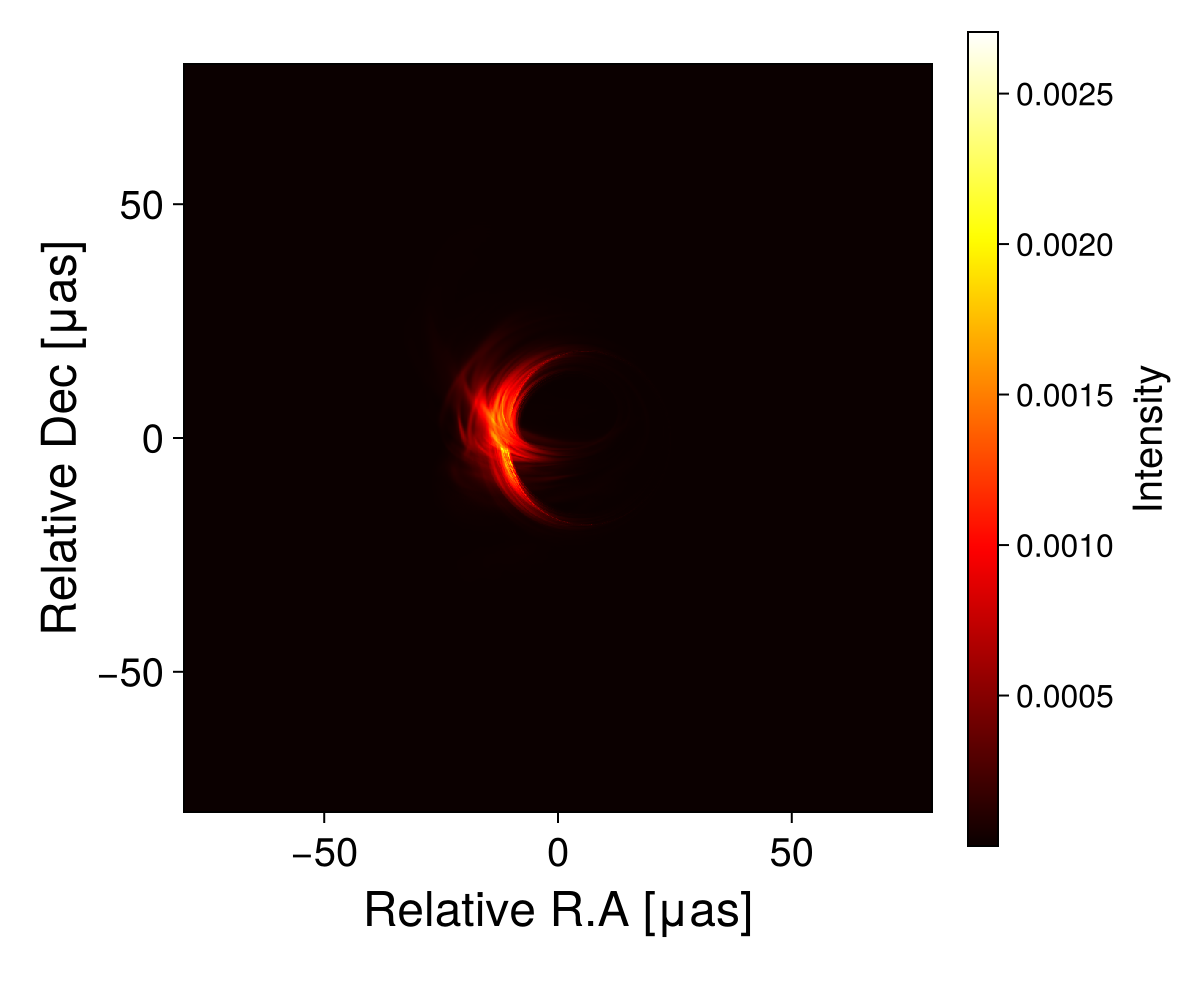

In [11]:
# ─── Visualización final de la imagen del agujero negro ──────────────────────

using CairoMakie   # Paquete de visualización de Julia para gráficos de alta calidad

# Distancia a M87* en kiloparsecs (unidad astronómica de distancia).
d_kpc = 16.9

# Conversión de kiloparsecs a centímetros: 1 kpc = 3.086e21 cm.
# Esta conversión es necesaria para calcular el ángulo proyectado en el cielo.
d_cm = d_kpc * 3.086e21

# Campo de visión total de la imagen en radios gravitacionales (ya calculado antes).
fov_rg = fovx

# Mitad del campo de visión: define el borde del plano imagen desde el centro.
half_fov_rg = fov_rg / 2

# Conversión del semiFOV de Rg a radianes:
# θ [rad] = (semiFOV [Rg] × L_unit [cm/Rg]) / d_cm
# L_unit es la longitud que corresponde a 1 Rg en centímetros (definida en main.jl).
theta_rad = (half_fov_rg * L_unit) / d_cm

# Conversión de radianes a microarcosegundos (μas), usando MUAS_PER_RAD.
# El resultado es el semiFOV angular de la imagen en μas, que es la unidad
# estándar para imágenes de núcleos galácticos activos en radio-interferometría.
theta_μas = theta_rad * MUAS_PER_RAD

# Límites del eje x e y de la imagen en μas (simétricas respecto al centro).
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Obtiene las dimensiones del arreglo Image (Ny filas, Nx columnas).
Ny, Nx = size(Image)

# Crea ejes de coordenadas lineales en μas para los ejes x e y de la imagen.
# range genera un vector de Nx (o Ny) puntos igualmente espaciados entre los límites.
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Crea la figura con tamaño 600×500 píxeles.
fig = Figure(size = (600, 500))

# Crea el sistema de ejes dentro de la figura (posición [1,1] de la grilla de la figura).
# Se definen etiquetas de ejes en ascensión recta (R.A.) y declinación (Dec),
# que son las coordenadas angulares estándar del cielo en radioastronomía.
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",   # Eje x: ascensión recta relativa en microarcosegundos
    ylabel = "Relative Dec [μas]",   # Eje y: declinación relativa en microarcosegundos
    xlabelsize = 24,
    ylabelsize = 24,
    xticklabelsize = 20,
    yticklabelsize = 20,
    limits = (xlims, ylims),         # Rango de los ejes en μas
    aspect = DataAspect()            # Mantiene la proporción 1:1 (píxeles cuadrados)
)

# Calcula el rango dinámico de la imagen: valor mínimo y máximo de intensidad.
# extrema devuelve (min, max) del arreglo Image.
crange = extrema(Image)

# heatmap!: dibuja la imagen de intensidad como un mapa de calor.
# - colormap = :hot → paleta de colores negro-rojo-amarillo-blanco,
#   estándar en imágenes de agujeros negros (similar a la imagen del EHT de M87*).
# - colorrange: mapea el rango dinámico completo de la imagen al rango de colores.
hm = heatmap!(ax, x, y, Image;
    colormap = :hot,
    colorrange = crange
)

# Agrega una barra de color (colorbar) a la derecha de la imagen (posición [1,2]).
# Indica la correspondencia entre color e intensidad específica Iν.
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

# Muestra la figura en la celda de salida del notebook.
fig


# Resumen: GenerateImageGRMHD

---

## PARTE 1 — Proceso de generación de la imagen

El notebook sigue un pipeline lineal de 6 pasos para producir una imagen sintética de un agujero negro a partir de datos de una simulación GRMHD.

---

### Paso 1 — Configuración del modelo
```julia
const MODEL = "iharm"
const MBH = 6.2e9
const SLOW_LIGHT = false
include("../src/main.jl")
```
Se definen tres variables globales antes de cargar Jipole. `include` las hereda directamente porque no crea un scope nuevo. El modelo `iharm` indica el formato del archivo de simulación. `SLOW_LIGHT = false` selecciona la prescripción de luz rápida.

---

### Paso 2 — Lectura del archivo GRMHD
```julia
const params = read_header(dump_filepath)
simulation_data[1] = load_data(dump_filepath, trat_large)
```
Se leen dos cosas distintas del archivo `.h5`:
- **`read_header`** extrae los metadatos: spin del agujero negro, tamaño de la grilla, coordenadas, unidades físicas.
- **`load_data`** extrae las variables primitivas del plasma (RHO, UU, B1, B2, B3...) y calcula las derived quantities (θe, ne, sigma, beta) usando `trat_large = 20` para la prescripción R-β.

---

### Paso 3 — Configuración del observador
```julia
const ro = 1000.0       # distancia en Rg
const th = 60.0         # inclinación en grados
const freq = 230e9      # frecuencia EHT en Hz
const res = 1024        # resolución de la imagen
```
Se define dónde está parado el observador y qué está midiendo. La frecuencia de 230 GHz corresponde a la del Event Horizon Telescope. La resolución de 1024 significa que se trazarán 1,048,576 geodésicas (una por píxel).

---

### Paso 4 — Ray tracing (el núcleo del cálculo)
```julia
Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid()
    for j in 0:(pixels_y - 1)
        nstep, _ = get_pixel(thread_trajs[tid], ...)
        integrate_emission!(thread_trajs[tid], nstep, Image, ...)
    end
end
Image *= freq^3
```
Para cada píxel se hacen dos operaciones en paralelo entre los 16 hilos:
1. `get_pixel`: traza la geodésica nula hacia atrás desde la cámara usando RK2 (hasta 15,000 pasos).
2. `integrate_emission!`: integra la ecuación de transferencia radiativa a lo largo de esa trayectoria, acumulando la intensidad en `Image[i,j]`.

Al final se multiplica por `freq³` para recuperar Iν en el marco del observador (corrección por invariante de Lorentz).

---

### Paso 5 — Conversión a unidades físicas
```julia
const scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)
```
La imagen en unidades internas se convierte a Jansky usando el factor de escala. Se reportan el flujo total (Fν), la intensidad máxima y promedio, y la luminosidad νLν.

---

### Paso 6 — Visualización
```julia
heatmap!(ax, x, y, Image; colormap = :hot, colorrange = crange)
```
Se grafica la imagen con los ejes en microarcosegundos (μas), que es la unidad angular estándar en radioastronomía. La paleta `:hot` (negro → rojo → amarillo → blanco) es la misma usada por el EHT para M87*.

---

### Resumen del pipeline completo

```
archivo .h5
    ↓ read_header + load_data
params + simulation_data
    ↓ configuración del observador
Xcamera + fov + freq
    ↓ get_pixel (RK2, 16 hilos)
thread_trajs[tid]  ← geodésicas
    ↓ integrate_emission!
Image (unidades internas)
    ↓ × freq³ × scale_factor
Image (Jansky)
    ↓ heatmap
imagen del agujero negro
```

---

---

## PARTE 2 — Conceptos de Julia aprendidos

---

### 1. `include` no crea un scope nuevo
```julia
const SLOW_LIGHT = false
include("../src/main.jl")  # SLOW_LIGHT es visible dentro de main.jl
```
A diferencia de `import` en Python, `include` pega el contenido del archivo directamente. Las variables definidas antes son heredadas.

---

### 2. `const` define constantes globales
```julia
const MBH = 6.2e9
```
Mejora el rendimiento porque Julia puede optimizar el tipo en tiempo de compilación. No significa que el valor sea inmutable en todos los casos: si es un contenedor (como un Vector), su contenido sí puede cambiar.

---

### 3. Interpolación de strings
```julia
include("./models/$(MODEL).jl")   # si MODEL = "iharm" → "./models/iharm.jl"
println("Hola $nombre")           # variables simples sin paréntesis
```
Equivalente a los f-strings de Python (`f"Hola {nombre}"`).

---

### 4. Structs como contenedores de datos
```julia
mutable struct OfTrajM
    dl::Float64
    X::MVec4
end
```
Agrupan variables relacionadas bajo un mismo nombre. `mutable` permite modificar los campos después de crear la instancia. El `::` declara el tipo de cada campo explícitamente para que Julia pueda optimizar el código.

---

### 5. `Vector{Tipo}(undef, n)` — reservar memoria sin inicializar
```julia
const simulation_data = Vector{IharmData}(undef, 1)
simulation_data[1] = load_data(...)
```
Reserva espacio para `n` elementos sin llenarlo todavía. Patrón común para crear contenedores globales mutables en Julia.

---

### 6. Paralelismo con `Threads.@threads`
```julia
Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    # cada hilo accede a su propio buffer thread_trajs[tid]
end
```
Distribuye el loop externo entre los hilos disponibles. Cada hilo debe tener su propio buffer para evitar condiciones de carrera. Las variables definidas dentro del loop son locales a él (no se filtran al scope exterior, a diferencia de Python).

---

### 7. Convención `!` para funciones que modifican argumentos
```julia
integrate_emission!(thread_trajs[tid], nstep, Image, ...)
```
El `!` es solo una convención de nomenclatura en Julia que avisa al lector que la función modifica alguno de sus argumentos (en este caso `Image`). No es sintaxis especial del lenguaje.

---

### 8. `@SVector` y `@MVector` — arrays en el stack
```julia
dummy_svec = @SVector zeros(4)   # inmutable, en stack, muy rápido
X = MVec4(...)                   # mutable, en stack
```
Para arrays pequeños de tamaño fijo (como vectores 4D en relatividad general), almacenarlos en el stack en lugar del heap es significativamente más rápido.

---

### 9. `@printf` para formato de precisión
```julia
@printf("Total Flux Fnu = %.15e Jy\n", Ftot)
```
Controla exactamente cuántos decimales se muestran y en qué formato. El `\n` es el salto de línea (no automático como en `println`). Útil para verificar resultados numéricos con alta precisión.

---

### 10. `;` al final suprime la salida
```julia
include("../src/main.jl");
```
Equivalente al `;` de MATLAB. Ejecuta pero no imprime el valor de retorno en el REPL o Jupyter.